# Fashion-MNIST Classification: CNN vs Random Forest

## Abstract
This report compares a convolutional neural network (CNN) implemented with TensorFlow/Keras against the best Random Forest configuration reported in the Fashion-MNIST benchmark introduced by Xiao, Rasul, and Vollgraf (2017). Both models use the canonical 60,000-image training set and 10,000-image test set. The notebook measures model-fit time, evaluates training and held-out test predictions, presents confusion matrices and per-class precision/recall, and bases the final recommendation on those results.

> Run all cells from top to bottom to reproduce the measurements. Training times depend on the machine and are recorded at runtime. The CNN follows the 2024 TensorFlow image-classification tutorial's preprocessing and training conventions, adapted to convolutional layers as required by this comparison.

## 1. Dataset
Fashion-MNIST contains 70,000 grayscale images of Zalando fashion products, each 28 by 28 pixels, assigned to one of ten mutually exclusive clothing categories. The official split has 60,000 training images (6,000 per category) and 10,000 test images (1,000 per category). The images are compact silhouettes rather than photographs of objects in arbitrary scenes; therefore, camera-based real-world item classification is outside the benchmark's scope.

The categories are T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, and Ankle boot. Each image is one byte per pixel in the original data, with intensities from 0 (black) to 255 (white). The canonical train/test split is retained; the test set is not used to choose hyperparameters.

## 2. Experimental design
A fixed random seed makes initialization and model randomness repeatable where the libraries allow it. The official test set remains untouched until final evaluation. For the CNN, pixel values are converted to float32 and scaled to [0, 1]. For the Random Forest, the benchmark's per-pixel standardization is fitted on training features only and then applied to test features; images are flattened from 28×28 to 784 predictors.

The Random Forest parameters are taken from the highest-accuracy RandomForestClassifier entry in the authors' published benchmark grid: entropy split criterion, maximum depth 50, and 100 trees. The benchmark used max depth 10, 50, and 100; gini and entropy; and 10, 50, and 100 trees. Its best reported forest scored 0.879 test accuracy. This notebook refits that configuration on the full official training split and reports its own measured result. The CNN and forest use the same official examples, but the CNN learns spatial filters while the forest treats each pixel as an independent feature.

In [1]:
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
assert x_train.shape == (60_000, 28, 28)
assert x_test.shape == (10_000, 28, 28)

x_train_cnn = x_train.astype(np.float32)[..., np.newaxis] / 255.0
x_test_cnn = x_test.astype(np.float32)[..., np.newaxis] / 255.0

print(f"Train: {x_train.shape}; test: {x_test.shape}")
print("Per-class train counts:", np.bincount(y_train))
print("Per-class test counts:", np.bincount(y_test))
print("Pixel range after CNN normalization:", float(x_train_cnn.min()), float(x_train_cnn.max()))

Train: (60000, 28, 28); test: (10000, 28, 28)
Per-class train counts: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]
Per-class test counts: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
Pixel range after CNN normalization: 0.0 1.0


## 3. Convolutional neural network

The CNN looks at each image as a small grid, so it can learn local details such as edges and the shapes that distinguish sleeves, soles, and bags. It uses two 3×3 convolution layers, each followed by 2×2 max pooling, then a 128-unit dense layer and a 10-score output layer. We train it for 10 epochs with batch size **126**, Adam at learning rate **0.001**, and sparse categorical cross-entropy. The test set is kept aside until evaluation.

The 2024 TensorFlow clothing tutorial provides the official dataset loader, pixel normalization, and Keras training approach. Its example network is fully connected rather than convolutional; the convolution and pooling layers here are the assignment's CNN adaptation.

## 4. Random Forest

For a fair classical baseline, each 28×28 image is flattened into 784 pixel features. A scaler is fitted on training images only, then used unchanged on test images. The forest uses the strongest configuration in the authors' published benchmark grid: 100 trees, entropy criterion, and maximum depth 50. We fix the random seed and use all CPU cores; timing includes fitting the scaler and forest, but not later predictions.

Trees do not understand that neighboring pixels belong together, unlike a CNN's image filters. That difference gives us a useful comparison between a familiar, relatively simple baseline and a model built to learn spatial patterns.

In [2]:
from tensorflow.keras import layers

cnn_model = tf.keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10),
])
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

cnn_started = time.perf_counter()
cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    batch_size=126,
    shuffle=True,
    verbose=2,
)
cnn_fit_seconds = time.perf_counter() - cnn_started
print(f"CNN fit time: {cnn_fit_seconds:.2f} seconds")

Epoch 1/10
477/477 - 49s - 103ms/step - accuracy: 0.8117 - loss: 0.5260
Epoch 2/10
477/477 - 50s - 105ms/step - accuracy: 0.8799 - loss: 0.3325
Epoch 3/10
477/477 - 49s - 102ms/step - accuracy: 0.8966 - loss: 0.2871
Epoch 4/10
477/477 - 50s - 104ms/step - accuracy: 0.9074 - loss: 0.2556
Epoch 5/10
477/477 - 47s - 99ms/step - accuracy: 0.9143 - loss: 0.2348
Epoch 6/10
477/477 - 47s - 99ms/step - accuracy: 0.9213 - loss: 0.2155
Epoch 7/10
477/477 - 47s - 99ms/step - accuracy: 0.9270 - loss: 0.1989
Epoch 8/10
477/477 - 47s - 99ms/step - accuracy: 0.9328 - loss: 0.1825
Epoch 9/10
477/477 - 47s - 98ms/step - accuracy: 0.9384 - loss: 0.1700
Epoch 10/10
477/477 - 47s - 99ms/step - accuracy: 0.9427 - loss: 0.1555
CNN fit time: 480.80 seconds


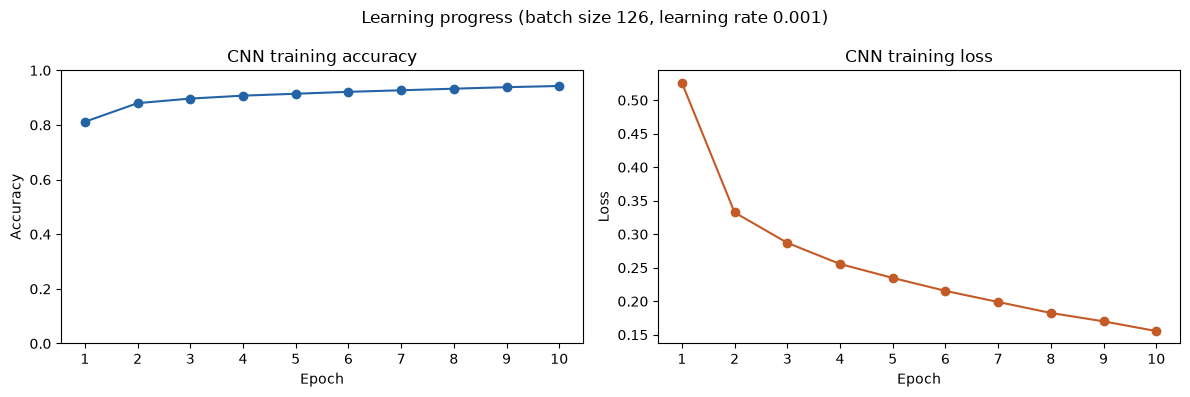

In [6]:
epochs = np.arange(1, len(cnn_history.history["accuracy"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, cnn_history.history["accuracy"], marker="o", color="#2463a6")
axes[0].set(title="CNN training accuracy", xlabel="Epoch", ylabel="Accuracy", xticks=epochs)
axes[0].set_ylim(0, 1)
axes[1].plot(epochs, cnn_history.history["loss"], marker="o", color="#c45a27")
axes[1].set(title="CNN training loss", xlabel="Epoch", ylabel="Loss", xticks=epochs)
fig.suptitle("Learning progress (batch size 126, learning rate 0.001)")
fig.tight_layout()
plt.show()

In [3]:
x_train_flat = x_train.reshape(len(x_train), -1).astype(np.float32)
x_test_flat = x_test.reshape(len(x_test), -1).astype(np.float32)

rf_model = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_depth=50,
        max_features="sqrt",
        random_state=SEED,
        n_jobs=-1,
    ),
)

rf_started = time.perf_counter()
rf_model.fit(x_train_flat, y_train)
rf_fit_seconds = time.perf_counter() - rf_started
print(f"Random Forest fit time: {rf_fit_seconds:.2f} seconds")

Random Forest fit time: 38.49 seconds


,Model,Split,Accuracy,Macro precision,Macro recall,Macro F1,Weighted precision,Weighted recall,Weighted F1
0,CNN,Train,0.954,0.955,0.954,0.953,0.955,0.954,0.953
1,CNN,Test,0.923,0.923,0.923,0.922,0.923,0.923,0.922
2,Random Forest,Train,1.000,1.000,1.000,1.000,1.000,1.000,1.000
3,Random Forest,Test,0.875,0.874,0.875,0.874,0.874,0.875,0.874


,Model,Split,Class,Precision,Recall,F1,Support
0,CNN,Train,T-shirt/top,0.873,0.962,0.915,6000
1,CNN,Train,Trouser,0.999,0.992,0.995,6000
2,CNN,Train,Pullover,0.944,0.899,0.921,6000
3,CNN,Train,Dress,0.948,0.976,0.962,6000
4,CNN,Train,Coat,0.899,0.945,0.921,6000
5,CNN,Train,Sandal,0.997,0.997,0.997,6000
6,CNN,Train,Shirt,0.918,0.802,0.856,6000
7,CNN,Train,Sneaker,0.991,0.977,0.983,6000
8,CNN,Train,Bag,0.999,0.998,0.998,6000
9,CNN,Train,Ankle boot,0.978,0.992,0.985,6000


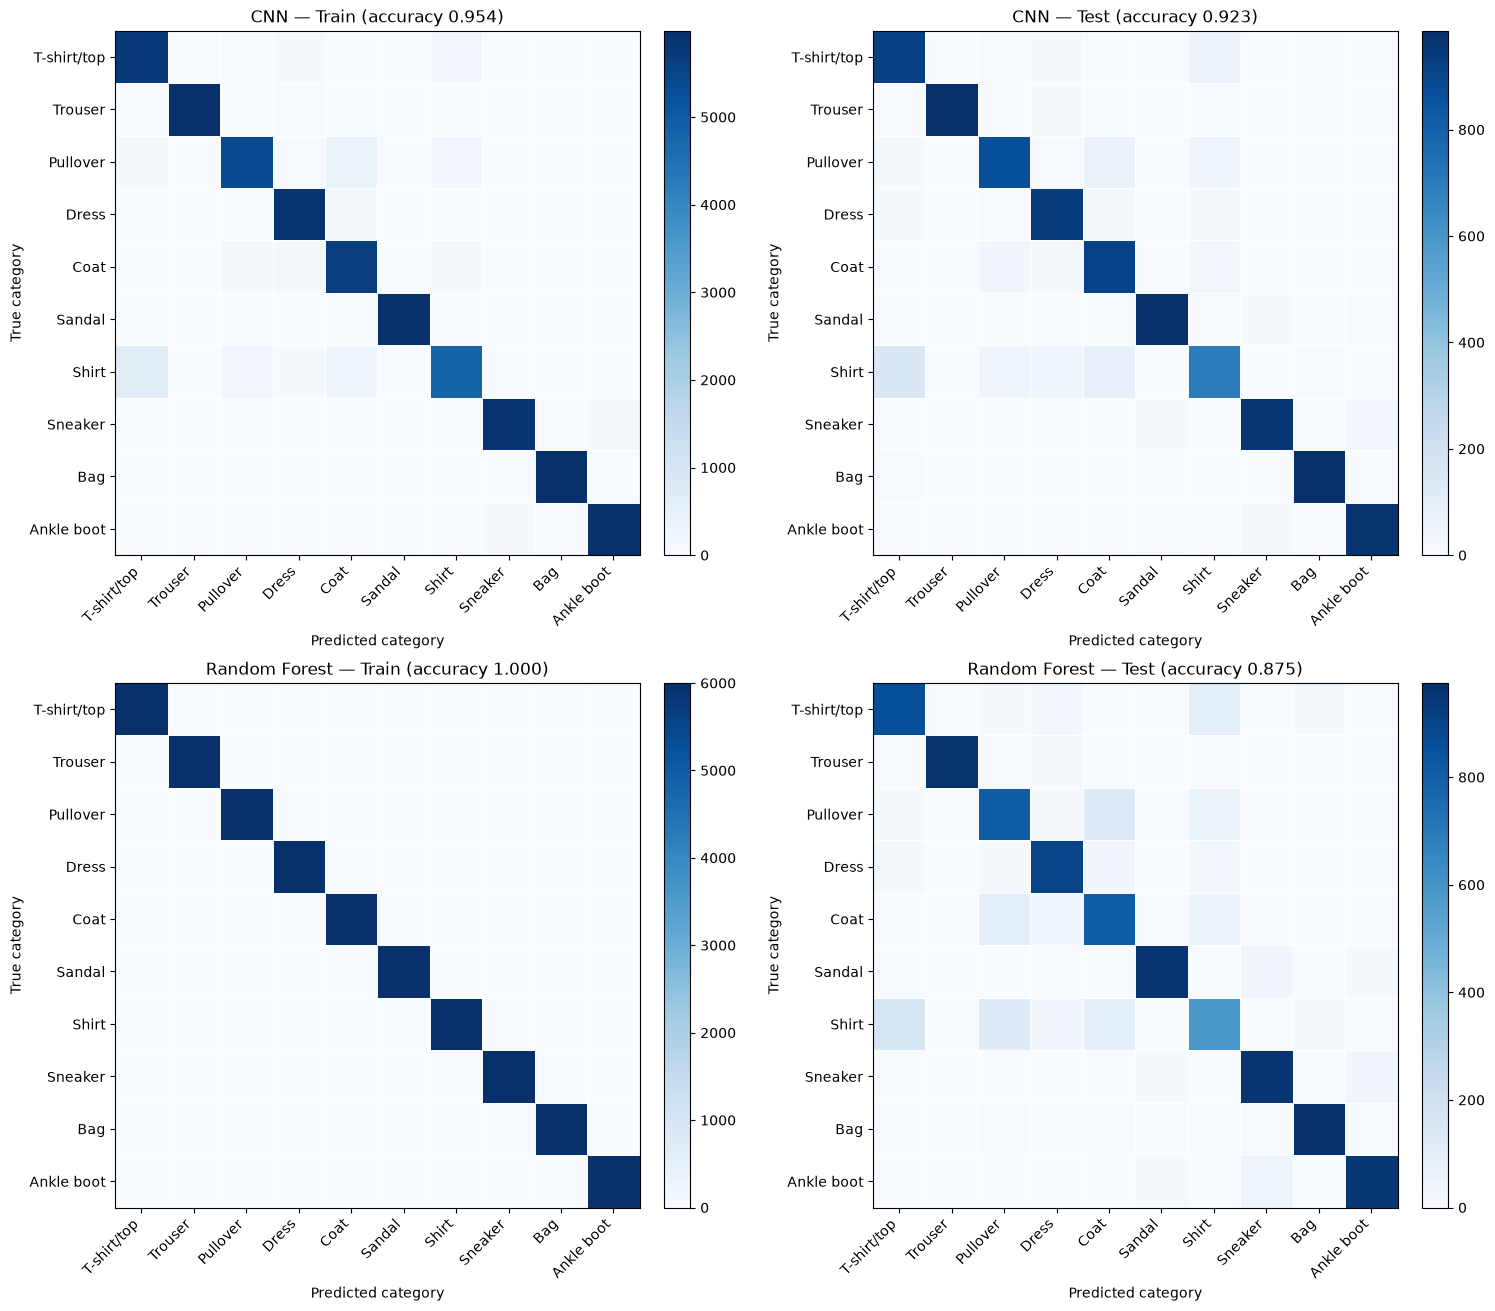

CNN: lowest test recall is Shirt (0.695); most frequent single test confusion is Shirt → T-shirt/top (149 images).
Random Forest: lowest test recall is Shirt (0.584); most frequent single test confusion is Shirt → T-shirt/top (156 images).


In [ ]:
cnn_train_pred = np.argmax(cnn_model.predict(x_train_cnn, batch_size=512, verbose=0), axis=1)
cnn_test_pred = np.argmax(cnn_model.predict(x_test_cnn, batch_size=512, verbose=0), axis=1)
rf_train_pred = rf_model.predict(x_train_flat)
rf_test_pred = rf_model.predict(x_test_flat)

predictions = {
    "CNN": {"Train": cnn_train_pred, "Test": cnn_test_pred},
    "Random Forest": {"Train": rf_train_pred, "Test": rf_test_pred},
}
labels = np.arange(len(CLASS_NAMES))

summary_rows = []
class_rows = []
confusion_matrices = {}
for model_name, split_predictions in predictions.items():
    for split_name, y_pred in split_predictions.items():
        y_true = y_train if split_name == "Train" else y_test
        matrix = confusion_matrix(y_true, y_pred, labels=labels)
        confusion_matrices[(model_name, split_name)] = matrix
        accuracy = accuracy_score(y_true, y_pred)
        macro_p, macro_r, macro_f, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=labels, average="macro", zero_division=0
        )
        weighted_p, weighted_r, weighted_f, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=labels, average="weighted", zero_division=0
        )
        summary_rows.append({
            "Model": model_name, "Split": split_name, "Accuracy": accuracy,
            "Macro precision": macro_p, "Macro recall": macro_r, "Macro F1": macro_f,
            "Weighted precision": weighted_p, "Weighted recall": weighted_r,
            "Weighted F1": weighted_f,
        })
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=labels, zero_division=0
        )
        for i, class_name in enumerate(CLASS_NAMES):
            class_rows.append({
                "Model": model_name, "Split": split_name, "Class": class_name,
                "Precision": precision[i], "Recall": recall[i],
                "F1": f1[i], "Support": support[i],
            })

summary_table = pd.DataFrame(summary_rows)
class_metrics = pd.DataFrame(class_rows)
display(summary_table.style.format({column: "{:.3f}" for column in summary_table.columns if column not in ("Model", "Split")}))
display(class_metrics.style.format({column: "{:.3f}" for column in ("Precision", "Recall", "F1")}))

fig, axes = plt.subplots(2, 2, figsize=(15, 13), constrained_layout=True)
for ax, (model_name, split_name) in zip(axes.flat, confusion_matrices):
    matrix = confusion_matrices[(model_name, split_name)]
    image = ax.imshow(matrix, cmap="Blues")
    threshold = matrix.max() / 2
    for row, column in np.ndindex(matrix.shape):
        value = matrix[row, column]
        ax.text(
            column, row, str(value), ha="center", va="center", fontsize=6,
            color="white" if value > threshold else "#17212b",
        )
    y_true = y_train if split_name == "Train" else y_test
    accuracy = accuracy_score(y_true, predictions[model_name][split_name])
    ax.set_title(f"{model_name} — {split_name} (accuracy {accuracy:.3f})")
    ax.set_xlabel("Predicted category")
    ax.set_ylabel("True category")
    ax.set_xticks(labels, CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(labels, CLASS_NAMES)
    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.show()

for model_name in predictions:
    test_metrics = class_metrics[(class_metrics["Model"] == model_name) & (class_metrics["Split"] == "Test")]
    worst = test_metrics.loc[test_metrics["Recall"].idxmin()]
    matrix = confusion_matrices[(model_name, "Test")].copy()
    np.fill_diagonal(matrix, 0)
    true_i, pred_i = np.unravel_index(np.argmax(matrix), matrix.shape)
    print(
        f"{model_name}: lowest test recall is {worst['Class']} ({worst['Recall']:.3f}); "
        f"most frequent single test confusion is {CLASS_NAMES[true_i]} → {CLASS_NAMES[pred_i]} "
        f"({matrix[true_i, pred_i]} images)."
    )

In [5]:
timing_table = pd.DataFrame([
    {"Model": "CNN", "Training time (seconds)": cnn_fit_seconds},
    {"Model": "Random Forest", "Training time (seconds)": rf_fit_seconds},
])
display(timing_table.style.format({"Training time (seconds)": "{:.2f}"}))

cnn_test_accuracy = summary_table.query("Model == 'CNN' and Split == 'Test'")["Accuracy"].iloc[0]
rf_test_accuracy = summary_table.query("Model == 'Random Forest' and Split == 'Test'")["Accuracy"].iloc[0]
cnn_train_accuracy = summary_table.query("Model == 'CNN' and Split == 'Train'")["Accuracy"].iloc[0]
rf_train_accuracy = summary_table.query("Model == 'Random Forest' and Split == 'Train'")["Accuracy"].iloc[0]
cnn_shirt = class_metrics.query("Model == 'CNN' and Split == 'Test' and Class == 'Shirt'").iloc[0]
rf_shirt = class_metrics.query("Model == 'Random Forest' and Split == 'Test' and Class == 'Shirt'").iloc[0]

print(
    f"On images the models had not seen during training, the CNN was correct on "
    f"{cnn_test_accuracy:.1%}, compared with {rf_test_accuracy:.1%} for the forest. "
    f"The CNN took {cnn_fit_seconds / 60:.1f} minutes to train; the forest took "
    f"{rf_fit_seconds:.1f} seconds. The forest memorized its training data "
    f"({rf_train_accuracy:.1%} training accuracy versus {rf_test_accuracy:.1%} test), "
    f"while the CNN's gap was smaller ({cnn_train_accuracy:.1%} versus {cnn_test_accuracy:.1%})."
)
print(
    f"Both models struggled most with shirts: test recall was {cnn_shirt['Recall']:.1%} "
    f"for the CNN and {rf_shirt['Recall']:.1%} for the forest. In both test confusion "
    f"matrices, Shirt → T-shirt/top was the most frequent individual error. That is "
    f"plausible because the grayscale thumbnails remove color, texture, and context, "
    f"leaving two similar upper-body silhouettes to distinguish."
)
print(
    "For this benchmark, I recommend the CNN for production when predictive quality "
    "matters more than training speed. It uses image structure and generalizes better "
    "on the held-out set. I would retain the forest as a fast, easy-to-inspect baseline; "
    "the 100% train score is not evidence that it is the more reliable model."
)

,Model,Training time (seconds)
0,CNN,480.80
1,Random Forest,38.49


On images the models had not seen during training, the CNN was correct on 92.3%, compared with 87.5% for the forest. The CNN took 8.0 minutes to train; the forest took 38.5 seconds. The forest memorized its training data (100.0% training accuracy versus 87.5% test), while the CNN's gap was smaller (95.4% versus 92.3%).
Both models struggled most with shirts: test recall was 69.5% for the CNN and 58.4% for the forest. In both test confusion matrices, Shirt → T-shirt/top was the most frequent individual error. That is plausible because the grayscale thumbnails remove color, texture, and context, leaving two similar upper-body silhouettes to distinguish.
For this benchmark, I recommend the CNN for production when predictive quality matters more than training speed. It uses image structure and generalizes better on the held-out set. I would retain the forest as a fast, easy-to-inspect baseline; the 100% train score is not evidence that it is the more reliable model.


## 5. Results and what they mean

The summary table above brings the main comparison together. On the held-out 10,000-image test set, the CNN reached **92.3% accuracy** and the Random Forest reached **87.5%**. That is a 4.8 percentage-point advantage for the CNN on unseen examples. The Random Forest is much quicker to fit on this machine (38.49 seconds versus 480.80 seconds for the CNN), but speed alone does not make it the better choice when errors matter.

The training scores tell an important part of the story. The forest classified all training images correctly, yet it dropped to 87.5% on test data. In other words, it learned the training examples extremely well but did not carry all of that performance over to new images. The CNN's training accuracy was 95.4% and its test accuracy was 92.3%; it still has a gap, but a smaller one. That pattern is consistent with better generalization, though it does not prove performance on photographs or future data outside this benchmark.

Precision answers, “When the model predicts this category, how often is it right?” Recall answers, “Of all real examples of this category, how many did it find?” The class-level table reports both measures for train and test data, with F1 and support for context. The summary table also gives macro averages (each category counts equally) and weighted averages (larger categories would count more; this benchmark is balanced, so they are close). Looking at per-class scores matters here: a strong overall accuracy can hide a category the model regularly misses.

## 6. Categories that caused trouble

Shirt was the hardest test category for both classifiers. The CNN found 69.5% of actual shirts, while the Random Forest found 58.4%. The most common single mistake for each was calling a shirt a T-shirt/top: 149 CNN errors and 156 forest errors. The diagrams show the rest of the category-to-category confusions directly, rather than hiding them inside the overall accuracy.

That result makes sense for this dataset. Every image is a small grayscale silhouette with no color, fabric texture, or surrounding context. Shirts, T-shirts, pullovers, and coats share a similar upper-body outline at 28×28 pixels, so some examples are genuinely difficult to separate. A CNN can use nearby pixel patterns and edges to build shape features; the forest sees a flattened list of pixel values and does not naturally preserve that neighborhood. This helps explain why the CNN did better, but it does not remove ambiguity in the labels or images.

The forest reached 100% training accuracy, which is a warning sign rather than a victory lap. Its test errors are concentrated in visually similar classes, especially shirts. The CNN still makes mistakes, but it balances performance across categories more evenly and has the higher held-out precision, recall, and F1 overall.

## 7. Recommendation

For this classification task, I would choose the CNN for production when the goal is to recognize the ten Fashion-MNIST categories reliably. It is 4.8 points more accurate on the untouched test split, its test macro precision and recall are about 0.923, and its smaller train/test gap suggests it transfers better to new examples from the same data source. The trade-off is training cost: this CPU run took about eight minutes, compared with under a minute for the forest. Once trained, either model can make predictions; this experiment did not benchmark serving latency or memory use.

I would keep the Random Forest as a useful baseline when training simplicity or a short fitting time matters more than the additional test accuracy. I would not deploy its 100%-training-score model without monitoring or further regularization, because the held-out result shows that memorizing the training set did not produce the best unseen predictions.

## 8. Limits and reproducibility

These results describe low-resolution grayscale product thumbnails, not a webcam looking at a person holding a garment. The notebook's benchmark is therefore separate from the live-camera demo in `main.py`; good Fashion-MNIST scores do not guarantee good real-world camera recognition. The archive supplied with the project contains T-shirt examples only, so it is not used in this ten-class experiment.

Training times are specific to this Mac's CPU, software versions, and current system load. The CNN was trained for ten epochs with batch size 126, learning rate 0.001, dropout 0.3, and seed 42. The forest used entropy, depth 50, 100 estimators, square-root feature sampling, and seed 42. The run uses the official 60,000/10,000 split, scales pixels to [0, 1] for the CNN, and fits the forest's StandardScaler only on training images. The test set was used only for final reporting, not model selection.

## References

Xiao, H., Rasul, K., & Vollgraf, R. (2017). *Fashion-MNIST: A novel image dataset for benchmarking machine learning algorithms*. arXiv:1708.07747. https://doi.org/10.48550/arXiv.1708.07747

TensorFlow. (2024). *Basic classification: Classify images of clothing*. https://www.tensorflow.org/tutorials/keras/classification

The Random Forest search grid and benchmark results are available in the [authors' repository](https://github.com/zalandoresearch/fashion-mnist) and its [benchmark page](http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/).

In [7]:
import json
from IPython.display import Markdown, display
from pathlib import Path

notebook_path = Path("Fashion_MNIST_Comparison.ipynb")
notebook_data = json.loads(notebook_path.read_text())
appendix_cells = [
    "".join(cell["source"])
    for cell in notebook_data["cells"]
    if cell["cell_type"] == "code"
    and "appendix_cells = [" not in "".join(cell["source"])
]
appendix = "\n\n".join(appendix_cells)
display(Markdown("## Appendix A. Complete analysis code\n\n```python\n" + appendix + "\n```"))

## Appendix A. Complete analysis code

```python
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
assert x_train.shape == (60_000, 28, 28)
assert x_test.shape == (10_000, 28, 28)

x_train_cnn = x_train.astype(np.float32)[..., np.newaxis] / 255.0
x_test_cnn = x_test.astype(np.float32)[..., np.newaxis] / 255.0

print(f"Train: {x_train.shape}; test: {x_test.shape}")
print("Per-class train counts:", np.bincount(y_train))
print("Per-class test counts:", np.bincount(y_test))
print("Pixel range after CNN normalization:", float(x_train_cnn.min()), float(x_train_cnn.max()))

from tensorflow.keras import layers

cnn_model = tf.keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10),
])
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

cnn_started = time.perf_counter()
cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    batch_size=126,
    shuffle=True,
    verbose=2,
)
cnn_fit_seconds = time.perf_counter() - cnn_started
print(f"CNN fit time: {cnn_fit_seconds:.2f} seconds")

epochs = np.arange(1, len(cnn_history.history["accuracy"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, cnn_history.history["accuracy"], marker="o", color="#2463a6")
axes[0].set(title="CNN training accuracy", xlabel="Epoch", ylabel="Accuracy", xticks=epochs)
axes[0].set_ylim(0, 1)
axes[1].plot(epochs, cnn_history.history["loss"], marker="o", color="#c45a27")
axes[1].set(title="CNN training loss", xlabel="Epoch", ylabel="Loss", xticks=epochs)
fig.suptitle("Learning progress (batch size 126, learning rate 0.001)")
fig.tight_layout()
plt.show()

x_train_flat = x_train.reshape(len(x_train), -1).astype(np.float32)
x_test_flat = x_test.reshape(len(x_test), -1).astype(np.float32)

rf_model = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_depth=50,
        max_features="sqrt",
        random_state=SEED,
        n_jobs=-1,
    ),
)

rf_started = time.perf_counter()
rf_model.fit(x_train_flat, y_train)
rf_fit_seconds = time.perf_counter() - rf_started
print(f"Random Forest fit time: {rf_fit_seconds:.2f} seconds")

cnn_train_pred = np.argmax(cnn_model.predict(x_train_cnn, batch_size=512, verbose=0), axis=1)
cnn_test_pred = np.argmax(cnn_model.predict(x_test_cnn, batch_size=512, verbose=0), axis=1)
rf_train_pred = rf_model.predict(x_train_flat)
rf_test_pred = rf_model.predict(x_test_flat)

predictions = {
    "CNN": {"Train": cnn_train_pred, "Test": cnn_test_pred},
    "Random Forest": {"Train": rf_train_pred, "Test": rf_test_pred},
}
labels = np.arange(len(CLASS_NAMES))

summary_rows = []
class_rows = []
confusion_matrices = {}
for model_name, split_predictions in predictions.items():
    for split_name, y_pred in split_predictions.items():
        y_true = y_train if split_name == "Train" else y_test
        matrix = confusion_matrix(y_true, y_pred, labels=labels)
        confusion_matrices[(model_name, split_name)] = matrix
        accuracy = accuracy_score(y_true, y_pred)
        macro_p, macro_r, macro_f, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=labels, average="macro", zero_division=0
        )
        weighted_p, weighted_r, weighted_f, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=labels, average="weighted", zero_division=0
        )
        summary_rows.append({
            "Model": model_name, "Split": split_name, "Accuracy": accuracy,
            "Macro precision": macro_p, "Macro recall": macro_r, "Macro F1": macro_f,
            "Weighted precision": weighted_p, "Weighted recall": weighted_r,
            "Weighted F1": weighted_f,
        })
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=labels, zero_division=0
        )
        for i, class_name in enumerate(CLASS_NAMES):
            class_rows.append({
                "Model": model_name, "Split": split_name, "Class": class_name,
                "Precision": precision[i], "Recall": recall[i],
                "F1": f1[i], "Support": support[i],
            })

summary_table = pd.DataFrame(summary_rows)
class_metrics = pd.DataFrame(class_rows)
display(summary_table.style.format({column: "{:.3f}" for column in summary_table.columns if column not in ("Model", "Split")}))
display(class_metrics.style.format({column: "{:.3f}" for column in ("Precision", "Recall", "F1")}))

fig, axes = plt.subplots(2, 2, figsize=(15, 13), constrained_layout=True)
for ax, (model_name, split_name) in zip(axes.flat, confusion_matrices):
    matrix = confusion_matrices[(model_name, split_name)]
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(f"{model_name} — {split_name} (accuracy {accuracy_score(y_train if split_name == 'Train' else y_test, predictions[model_name][split_name]):.3f})")
    ax.set_xlabel("Predicted category")
    ax.set_ylabel("True category")
    ax.set_xticks(labels, CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(labels, CLASS_NAMES)
    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.7)
    ax.tick_params(which="minor", bottom=False, left=False)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.show()

for model_name in predictions:
    test_metrics = class_metrics[(class_metrics["Model"] == model_name) & (class_metrics["Split"] == "Test")]
    worst = test_metrics.loc[test_metrics["Recall"].idxmin()]
    matrix = confusion_matrices[(model_name, "Test")].copy()
    np.fill_diagonal(matrix, 0)
    true_i, pred_i = np.unravel_index(np.argmax(matrix), matrix.shape)
    print(
        f"{model_name}: lowest test recall is {worst['Class']} ({worst['Recall']:.3f}); "
        f"most frequent single test confusion is {CLASS_NAMES[true_i]} → {CLASS_NAMES[pred_i]} "
        f"({matrix[true_i, pred_i]} images)."
    )

timing_table = pd.DataFrame([
    {"Model": "CNN", "Training time (seconds)": cnn_fit_seconds},
    {"Model": "Random Forest", "Training time (seconds)": rf_fit_seconds},
])
display(timing_table.style.format({"Training time (seconds)": "{:.2f}"}))

cnn_test_accuracy = summary_table.query("Model == 'CNN' and Split == 'Test'")["Accuracy"].iloc[0]
rf_test_accuracy = summary_table.query("Model == 'Random Forest' and Split == 'Test'")["Accuracy"].iloc[0]
cnn_train_accuracy = summary_table.query("Model == 'CNN' and Split == 'Train'")["Accuracy"].iloc[0]
rf_train_accuracy = summary_table.query("Model == 'Random Forest' and Split == 'Train'")["Accuracy"].iloc[0]
cnn_shirt = class_metrics.query("Model == 'CNN' and Split == 'Test' and Class == 'Shirt'").iloc[0]
rf_shirt = class_metrics.query("Model == 'Random Forest' and Split == 'Test' and Class == 'Shirt'").iloc[0]

print(
    f"On images the models had not seen during training, the CNN was correct on "
    f"{cnn_test_accuracy:.1%}, compared with {rf_test_accuracy:.1%} for the forest. "
    f"The CNN took {cnn_fit_seconds / 60:.1f} minutes to train; the forest took "
    f"{rf_fit_seconds:.1f} seconds. The forest memorized its training data "
    f"({rf_train_accuracy:.1%} training accuracy versus {rf_test_accuracy:.1%} test), "
    f"while the CNN's gap was smaller ({cnn_train_accuracy:.1%} versus {cnn_test_accuracy:.1%})."
)
print(
    f"Both models struggled most with shirts: test recall was {cnn_shirt['Recall']:.1%} "
    f"for the CNN and {rf_shirt['Recall']:.1%} for the forest. In both test confusion "
    f"matrices, Shirt → T-shirt/top was the most frequent individual error. That is "
    f"plausible because the grayscale thumbnails remove color, texture, and context, "
    f"leaving two similar upper-body silhouettes to distinguish."
)
print(
    "For this benchmark, I recommend the CNN for production when predictive quality "
    "matters more than training speed. It uses image structure and generalizes better "
    "on the held-out set. I would retain the forest as a fast, easy-to-inspect baseline; "
    "the 100% train score is not evidence that it is the more reliable model."
)
```